# Data Overview

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/Mate\ academy
# import CSV file
products_data = pd.read_csv("products.csv")
events_data = pd.read_csv("events.csv")
countries_data = pd.read_csv("countries.csv")

Mounted at /content/drive
/content/drive/MyDrive/Mate academy


In [ ]:
# Перевірка даних
print("products_data:")
print(products_data.head())

print("\nevents_data:")
print(events_data.head())

print("\ncountries_data:")
print(countries_data.head())

products_data:
     id        item_type
0  2103           Cereal
1  7940        Household
2  2455          Clothes
3  1270        Beverages
4  8681  Office Supplies

events_data:
    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  

countries_data:
           

In [ ]:
# Розмір таблиць
print("Products Data Shape:", products_data.shape)
print("Events Data Shape:", events_data.shape)
print("Countries Data Shape:", countries_data.shape)

Products Data Shape: (12, 2)
Events Data Shape: (1330, 10)
Countries Data Shape: (249, 5)


In [ ]:
# Інформація по таблицях
print("products_data:")
print(products_data.info())
print("\nevents_data:")
print(events_data.info())
print("\ncountries_data:")
events_data.info()

products_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
None

events_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes

In [ ]:
# Типи даних у таблицях
print("products_data:")
print(products_data.dtypes)
print("\nevents_data:")
print(events_data.dtypes)
print("\ncountries_data:")
print(countries_data.dtypes)

products_data:
id            int64
item_type    object
dtype: object

events_data:
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object

countries_data:
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object


## Опис змінних для кожної таблиці

Таблиця product_data:
- id — унікальний ідентифікатор продукту.
- item_type — категорія або тип товару.

Таблиця event_data:
- Order ID — унікальний ідентифікатор замовлення.
- Order Date — дата створення замовлення.
- Ship Date — дата відправлення товару.
- Order Priority — пріоритет замовлення.
- Country Code — код країни, в якій здійснено замовлення.
- Product ID — ідентифікатор товару. Збігається з id у таблиці product_data.
- Sales Channel — канал продажу: Online / Offline.
- Units Sold — кількість проданих одиниць.
- Unit Price — ціна за одиницю товару.
- Unit Cost — собівартість одиниці товару.

Таблиця countries_data:
- name — назва країни.
- alpha-2 — дволітерний код країни ISO 3166-1.
- alpha-3 — трилітерний ISO 3166-1.
- region — географічний регіон.
- sub-region — субрегіон.

## Ключові поля, що поєднують три таблиці

- events_data.Product ID   →   products_data.id

-  events_data.Country Code →   countries_data.alpha-3


# Data cleaning

In [ ]:
# Пропущені значення у таблицях
print("products_data:")
print(products_data.isna().sum())
print("\nevents_data:")
print(events_data.isna().sum())
print("\ncountries_data:")
print(countries_data.isna().sum())

products_data:
id           0
item_type    0
dtype: int64

events_data:
Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64

countries_data:
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


In [ ]:
# Відсоток пропущених значень у таблицях
print("products_data:")
print(products_data.isna().sum() / products_data.shape[0] * 100)
print("\n:")
print(events_data.isna().sum() / events_data.shape[0] * 100)
print("\ncountries_data:")
print(countries_data.isna().sum() / countries_data.shape[0] * 100)

products_data:
id           0.0
item_type    0.0
dtype: float64

:
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64

countries_data:
name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


У таблиці products_data всі значення заповнені.

У таблиці events_data пропущені значення є в стовпцях:
*   Units Sold. Доля пропущених значень не перевищує 0.15%, можна видалити рядки з пропущеними значеннями. Можлива причина відсутності даних - не вказана інформація;
*   Country Code. Доля пропущених значень складає 6.16%, можна видалити рядки з пропущеними значеннями. Можливі причини відсутності даних: відсутність даних про країну у вихідній системі або дані не були вказані.

У таблиці countries_data пропущені значення є в стовпцях:
*   alpha-2;
*   region;
*   sub-region.

Доля пропущених значень не перевищує 0.4%, можна видалити рядки з пропущеними значеннями.  Можлива причина відсутності даних - деякі території не мають визначеної географічної класифікації.

In [ ]:
# Видалення пропущених значень у таблицях
events_clean = events_data.dropna()
countries_clean = countries_data.dropna()

In [ ]:
# Перевірка видалення пропущених значень у таблицях
print("events_data:")
print(events_clean.isna().sum())
print("\ncountries_data:")
print(countries_clean.isna().sum())

events_data:
Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
dtype: int64

countries_data:
name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64


In [ ]:
# Перетворення стовпців 'Order Date' та 'Ship Date' до формату datetime
events_data['Order Date'] = pd.to_datetime(events_data['Order Date'], errors='coerce')
events_data['Ship Date'] = pd.to_datetime(events_data['Ship Date'], errors='coerce')

print(events_data.dtypes)

Order ID                   int64
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Order Priority            object
Country Code              object
Product ID                 int64
Sales Channel             object
Units Sold               float64
Unit Price               float64
Unit Cost                float64
dtype: object


In [ ]:
# Перевірка даних на наявність дублікатів
print("products_data:")
print(products_data.duplicated().sum())
print("\nevents_data:")
print(events_data.duplicated().sum())
print("\ncountries_data:")
print(countries_data.duplicated().sum())

products_data:
0

events_data:
0

countries_data:
0


In [ ]:
# Очищення даних від зайвих пробілів та перетворення в нижній регістр
products_data['item_type'] = products_data['item_type'].str.strip()
events_data['Sales Channel'] = events_data['Sales Channel'].str.strip()
events_data['Country Code'] = events_data['Country Code'].str.strip()
countries_data['name'] = countries_data['name'].str.strip()
countries_data['alpha-2'] = countries_data['alpha-2'].str.strip()
countries_data['alpha-3'] = countries_data['alpha-3'].str.strip()
countries_data['region'] = countries_data['region'].str.strip()
countries_data['sub-region'] = countries_data['sub-region'].str.strip()

In [ ]:
# Дескриптивна статистика для таблиці events_data
print(events_data.describe())

           Order ID                     Order Date  \
count  1.330000e+03                           1330   
mean   5.412048e+08  2013-10-12 06:09:12.180451072   
min    1.006406e+08            2010-01-01 00:00:00   
25%    3.190004e+08            2011-12-16 06:00:00   
50%    5.387164e+08            2013-10-17 00:00:00   
75%    7.544628e+08            2015-08-28 18:00:00   
max    9.998797e+08            2017-07-23 00:00:00   
std    2.573882e+08                            NaN   

                           Ship Date   Product ID   Units Sold   Unit Price  \
count                           1330  1330.000000  1328.000000  1330.000000   
mean   2013-11-06 00:46:33.383458816  5788.096241  4952.201807   264.893541   
min              2010-01-10 00:00:00  1270.000000     2.000000     9.330000   
25%              2012-01-03 00:00:00  3127.000000  2356.750000    81.730000   
50%              2013-11-09 00:00:00  5988.000000  4962.000000   154.060000   
75%              2015-10-03 18:00:00  8

Аномалій не виявлено.

# Data analysis and visualization

In [ ]:
# Об’єднання трьох таблиць в один датафрейм
merged_data = pd.merge(
    events_data,
    products_data,
    left_on="Product ID",
    right_on="id",
    how="inner"
    )

final_merged_data = pd.merge(
    merged_data,
    countries_data,
    left_on="Country Code",
    right_on="alpha-3",
    how="inner"
)

# Видалення непотрібних колонок
final_merged_data = final_merged_data.drop(columns=["alpha-3", "alpha-2", "id"])

# Перейменування колонок
final_merged_data = final_merged_data.rename(columns={"name": "Country Name"})

final_merged_data.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,item_type,Country Name,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe


In [ ]:
# Загальна кількість замовлень
total_orders = final_merged_data['Order ID'].nunique()
print("Загальна кількість замовлень:", total_orders)

# Загальна кількість проданих одиниць
total_units_sold = final_merged_data['Units Sold'].sum()
print("Загальна кількість проданих одиниць:", total_units_sold)

# Загальна кількість охоплених країн
total_countries = final_merged_data['Country Name'].nunique()
print("Загальна кількість охоплених країн:", total_countries)

# Загальна кількість охоплених регіонів
total_regions = final_merged_data['region'].nunique()
print("Загальна кількість охоплених регіонів:", total_regions)

# Загальний дохід
total_revenue = (final_merged_data['Units Sold'] * final_merged_data['Unit Price']).sum()
print("Загальний дохід:", total_revenue)

# Загальні витрати
total_cost = (final_merged_data['Units Sold'] * final_merged_data['Unit Cost']).sum()
print("Загальні витрати:", total_cost)

# Загальний прибуток
total_profit = total_revenue - total_cost
print("Загальний прибуток:", total_profit)

# Середній інтервал часу (в днях) від замовлення до відвантаження
final_merged_data['Shipping Time (Days)'] = (final_merged_data['Ship Date'] - final_merged_data['Order Date']).dt.days
average_shipping_time = final_merged_data['Shipping Time (Days)'].mean()
print("Середній інтервал часу від замовлення до відвантаження (дні):", average_shipping_time)

Загальна кількість замовлень: 1248
Загальна кількість проданих одиниць: 6171671.0
Загальна кількість охоплених країн: 45
Загальна кількість охоплених регіонів: 2
Загальний дохід: 1598983761.2600002
Загальні витрати: 1125274726.2
Загальний прибуток: 473709035.0600002
Середній інтервал часу від замовлення до відвантаження (дні): 24.86378205128205


In [ ]:
# Додаємо нові колонки
final_merged_data.loc[:, "total_revenue"] = final_merged_data['Units Sold'] * final_merged_data['Unit Price']
final_merged_data.loc[:, "total_cost"] = final_merged_data['Units Sold'] * final_merged_data['Unit Cost']
final_merged_data.loc[:, "total_profit"] = final_merged_data["total_revenue"] - final_merged_data["total_cost"]

In [ ]:
from matplotlib.ticker import FuncFormatter

# Функція форматування осей
def millions(x, pos):
    return f'{int(x / 1_000_000)}M'

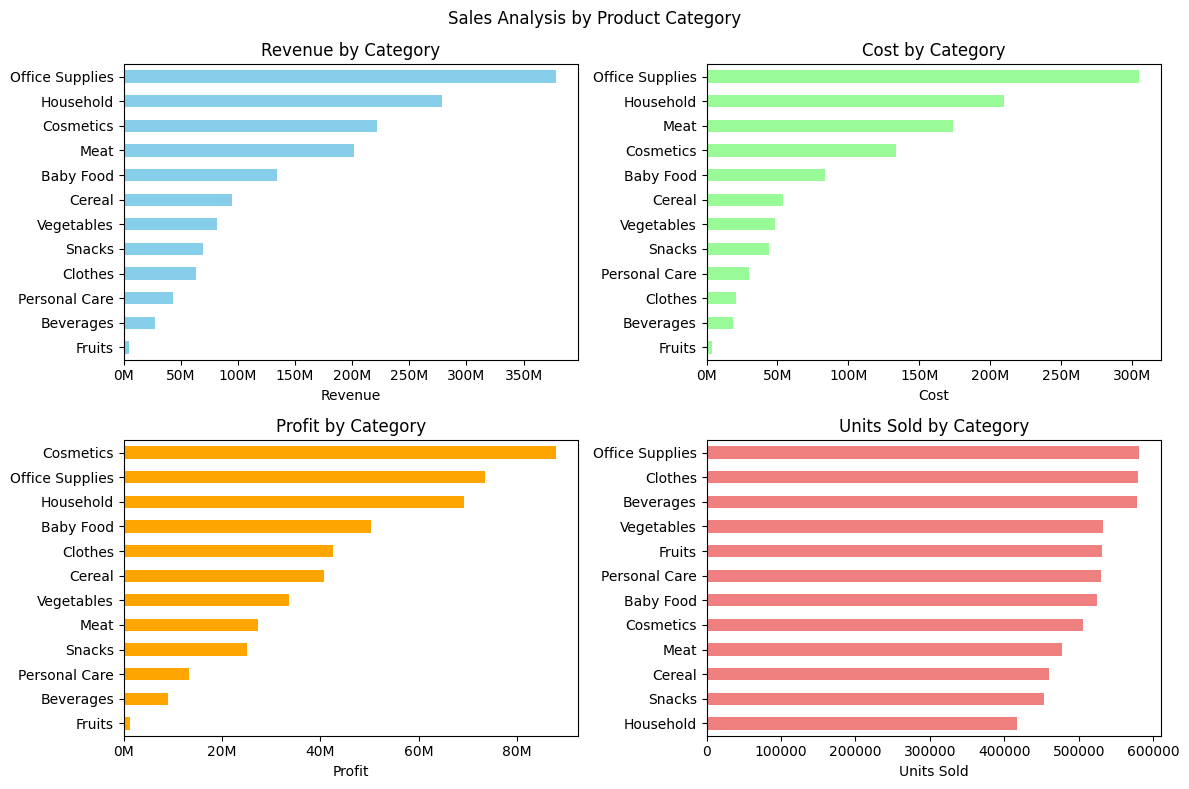

In [ ]:
# Візуалізація
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Sales Analysis by Product Category')

# Загальний дохід
final_merged_data.groupby('item_type', observed=False)['total_revenue'].sum().sort_values().plot(
    kind='barh', ax=axes[0, 0], color='skyblue', title='Revenue by Category')
axes[0, 0].set_xlabel('Revenue')
axes[0, 0].set_ylabel('')
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(millions))

# Загальні витрати
final_merged_data.groupby('item_type', observed=False)['total_cost'].sum().sort_values().plot(
    kind='barh', ax=axes[0, 1], color='palegreen', title='Cost by Category')
axes[0, 1].set_xlabel('Cost')
axes[0, 1].set_ylabel('')
axes[0, 1].xaxis.set_major_formatter(FuncFormatter(millions))

# Загальний прибуток
final_merged_data.groupby('item_type', observed=False)['total_profit'].sum().sort_values().plot(
    kind='barh', ax=axes[1, 0], color='orange', title='Profit by Category')
axes[1, 0].set_xlabel('Profit')
axes[1, 0].set_ylabel('')
axes[1, 0].xaxis.set_major_formatter(FuncFormatter(millions))

# Кількість проданих одиниць
final_merged_data.groupby('item_type', observed=False)['Units Sold'].sum().sort_values().plot(
    kind='barh', ax=axes[1, 1], color='lightcoral', title='Units Sold by Category')

axes[1, 1].set_xlabel('Units Sold')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

## Опис візуалізації

1. Revenue by Category (Дохід за категоріями).

   * Найбільший дохід приносить Office Supplies, далі йдуть Household та Cosmetics.
   * Найменший дохід – у Fruits, Beverages та Personal Care.

2. Cost by Category (Витрати за категоріями).

   * Найбільші витрати – теж на Office Supplies і Household.
   * Витрати на Cosmetics нижчі, ніж доходи, що позитивно впливає на маржу.
   * Найменші витрати у Fruits, але вона приносить і наймеший дохід.

3. Profit by Category (Прибуток за категоріями).

   * Найприбутковіші категорії: Cosmetics, Office Supplies, Household.
   * Meat та Snacks приносять менше прибутку, хоча можуть мати значні витрати.
   * Fruits та Beverages – мінімальний прибуток.

4. Units Sold by Category (Кількість проданих одиниць).

   * Найбільше одиниць продається у Office Supplies, Clothes та Beverages.
   * Найменше продається Household та Snacks.
   * Clothes продаються добре, але їх прибуток нижчий, ніж у Cosmetics.

## Бізнес-висновки
   * Cosmetics, Office Supplies, Household – ці категорії формують більшість прибутку і варто підтримувати їхній асортимент та маркетинг.
   * Категорії з високим доходом, але низьким прибутком: Meat, Snacks. Потрібно оптимізувати витрати або ціну на ці категорії.
   * Категії з низьким доходом і низьким прибутком: Fruits, Beverages. Варто переглянути стратегію – або підвищити маржу, або скоротити витрати.
   * Обсяг продажів не завжди співпадає з прибутком – важливо орієнтуватися не тільки на кількість проданих одиниць, а й на маржинальність.

Стратегія розвитку: інвестувати у категорії з високим прибутком і середнім обсягом продажів (Cosmetics), оптимізувати витрати у великих категоріях з високим обсягом продажів (Meat, Household).

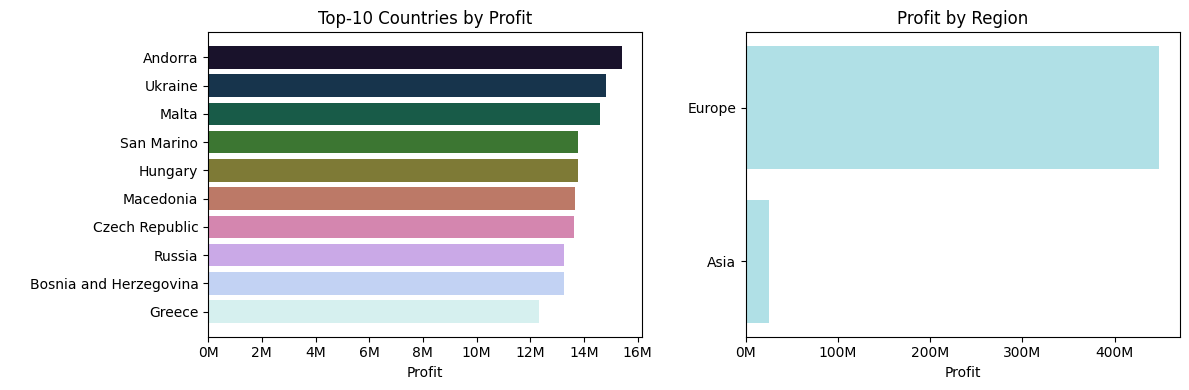

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Топ 10 країн за прибутком
top10 = (final_merged_data.groupby("Country Name")["total_profit"].sum().sort_values(ascending=False).head(10))
colors = sns.color_palette("cubehelix", len(top10))
ax[0].barh(top10.index, top10.values, color=colors)
ax[0].set_title("Top-10 Countries by Profit")
ax[0].set_xlabel("Profit")
ax[0].set_ylabel(" ")
ax[0].xaxis.set_major_formatter(FuncFormatter(millions))
ax[0].invert_yaxis()

# Прибуток за регіонами
region_revenue = final_merged_data.groupby('region')['total_profit'].sum()
ax[1].barh(region_revenue.index, region_revenue.values, color='powderblue')
ax[1].set_title("Profit by Region")
ax[1].set_xlabel("Profit")
ax[1].set_ylabel(" ")
ax[1].xaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

## Опис візуалізації

1. Top-10 Countries by Profit (Toп-10 країн за прибутком).

   * Очевидні лідери: Andorra, Ukraine, Malta, San Marino. Всі вони мають приблизно однаковий прибуток (14–15 млн).
   * Середній прибуток: San Marino, Hungary, Macedonia, Czech Republic, Russia, Bosnia and Herzegovina (приблизно 13 млн).
   * Найнижчий прибуток у топ-10: Greece (приблизно 12 млн).
2. Profit by Region (Прибуток за регіоном)
   * Європа домінує з величезним відривом (приблизно 450 млн).
   * Азія має значно менший прибуток (приблизно 25 млн).

## Бізнес-висновки
   
   * Є чітка концентрація прибутку у невеликій групі європейських країн. Можливо, стратегія продажів або маркетингові кампанії працюють ефективніше у цих країнах.
   * Для росту прибутку варто посилити продажі у країнах, де прибуток зараз нижчий.
   * Європа є основним ринком для компанії, що може бути пов’язано з високим попитом, ціновою політикою або оптимальною логістикою.
   * Варто дослідити причини низького прибутку в Азії (можливо складності з доставкою або слабкий маркетинг).

Стратегія розвитку: основні ресурси доцільно концентрувати на європейських країнах, де прибуток вже високий та запустити локалізовані маркетингові кампанії в країнах Азії.

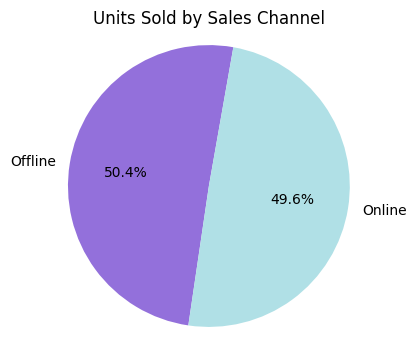

In [ ]:
# Приведення значень у полі 'Sales Channel' до єдиного формату
final_merged_data['Sales Channel'] = final_merged_data['Sales Channel'].str.capitalize()

# Кількість проданих одиниць за каналами продажу
channels = final_merged_data.groupby('Sales Channel')['Units Sold'].sum()

plt.figure(figsize=(4,4))
plt.pie(channels, labels=channels.index, autopct='%1.1f%%', startangle=80, colors=["mediumpurple", "powderblue"])
plt.title("Units Sold by Sales Channel")
plt.axis('equal')
plt.show()

## Опис візуалізації

Units Sold by Sales Channel (Продані одиниці за каналами продажу)
   * Offline: 50.4%.
   * Online: 49.6%.

## Бізнес-висновки
   * Онлайн-продажі становлять майже половину, але трохи менше за офлайн. Можна розглянути інвестиції у цифровий маркетинг, наприклад, покращення вебсайту чи мобільного додатку.

Стратегія розвитку: обидва канали є критично важливими для підтримки поточного обсягу продажів, стратегічний підхід полягає у підтримці та оптимізації інвестицій в обидва напрямки.

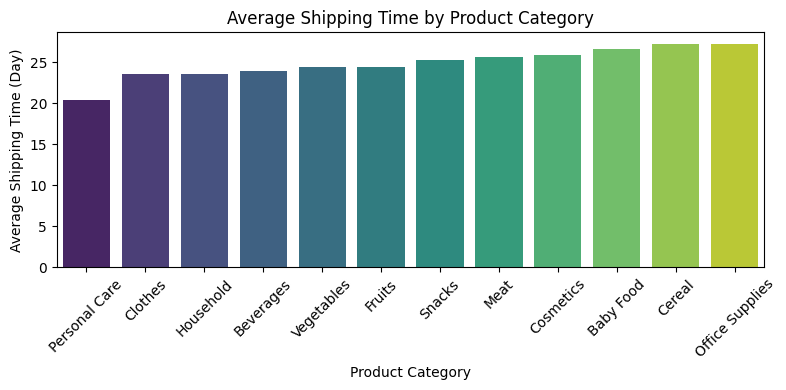

In [ ]:
# Обчислюємо інтервал часу між замовленням та відвантаженням у днях
final_merged_data['shipping_time_days'] = (final_merged_data['Ship Date'] - final_merged_data['Order Date']).dt.days

# Середньій інтервал часу за категоріями товарів
avg_shipping_time = final_merged_data.groupby('item_type')['shipping_time_days'].mean().reset_index()
avg_shipping_time = avg_shipping_time.sort_values(by='shipping_time_days', ascending=True)

plt.figure(figsize=(8, 4))
sns.barplot(data=avg_shipping_time, x='item_type', y='shipping_time_days', hue='item_type', dodge=False, palette='viridis')
plt.title('Average Shipping Time by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Shipping Time (Day)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

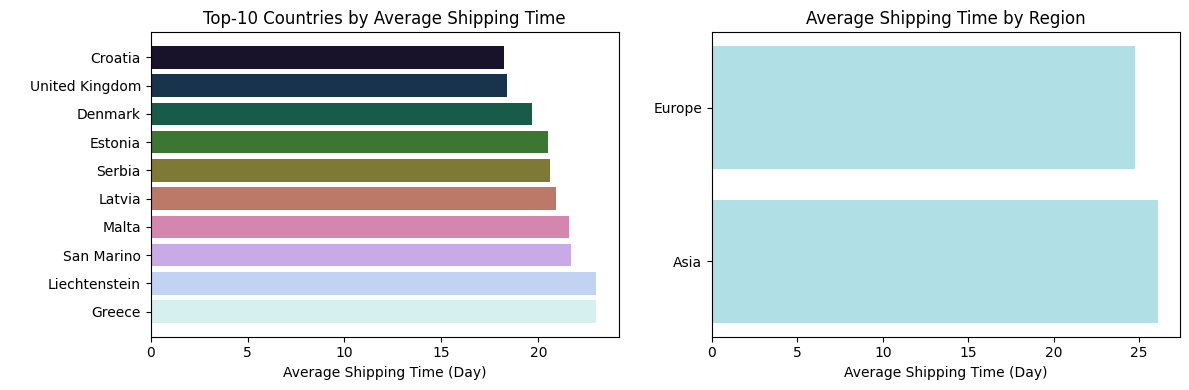

In [ ]:
colors = sns.color_palette("cubehelix", len(top10))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Cередній інтервал часу за країнами
top10_shipping = (final_merged_data.groupby("Country Name")["shipping_time_days"].mean().sort_values(ascending=True).head(10))
ax[0].barh(top10_shipping.index, top10_shipping.values, color=colors)
ax[0].set_title("Top-10 Countries by Average Shipping Time")
ax[0].set_xlabel("Average Shipping Time (Day)")
ax[0].set_ylabel(" ")
ax[0].invert_yaxis()

# Cередній інтервал часу за регіонами
region_shipping = final_merged_data.groupby('region')['shipping_time_days'].mean()
ax[1].barh(region_shipping.index, region_shipping.values, color='powderblue')
ax[1].set_title("Average Shipping Time by Region")
ax[1].set_xlabel("Average Shipping Time (Day)")
ax[1].set_ylabel(" ")

plt.tight_layout()
plt.show()

In [ ]:
# Кореляція між часом доставки і прибутком
corr = final_merged_data["shipping_time_days"].corr(final_merged_data["total_profit"])
print("Кореляція між часом доставки і прибутком:", corr)

Кореляція між часом доставки і прибутком: 0.06069452759496703


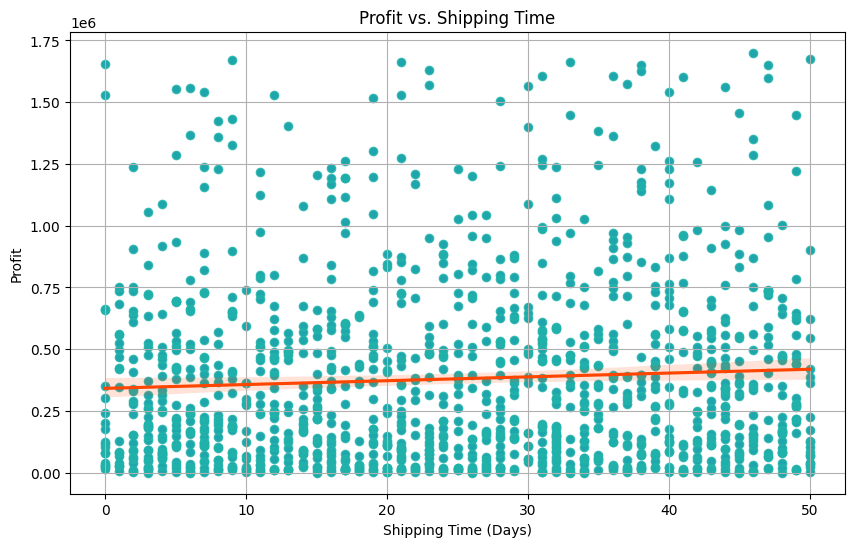

In [ ]:
# Залежність прибутку від часу доставки
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=final_merged_data,
    x="shipping_time_days",
    y="total_profit",
)
sns.regplot(
    data=final_merged_data,
    x="shipping_time_days",
    y="total_profit",
    scatter_kws={"color": "lightseagreen"},
    line_kws={"color": "orangered"},
)

plt.title("Profit vs. Shipping Time")
plt.xlabel("Shipping Time (Days)")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

## Опис візуалізації

   * Розподіл точок: кожна точка на графіку представляє окреме замовлення, де діапазон часу відвантаження від 0 до 50 днів і діапазон прибутку приблизно від 0 до 1.75 млн.
   * Лінія регресії: показує тренд між часом доставки та прибутком. На графіку видно, що лінія має ледь помітний позитивний нахил, що вказує на незначну тенденцію до зростання прибутку зі збільшенням часу доставки.

## Бізнес-висновки
   * Слабка кореляція між часом доставки та прибутком означає, що прибуток практично не залежить від часу відвантаження.

Стратегія розвитку: оскільки час відвантаження не є ключовим генератором прибутку, слід зосередитися на оптимізації факторів, які дійсно впливають на прибуток.

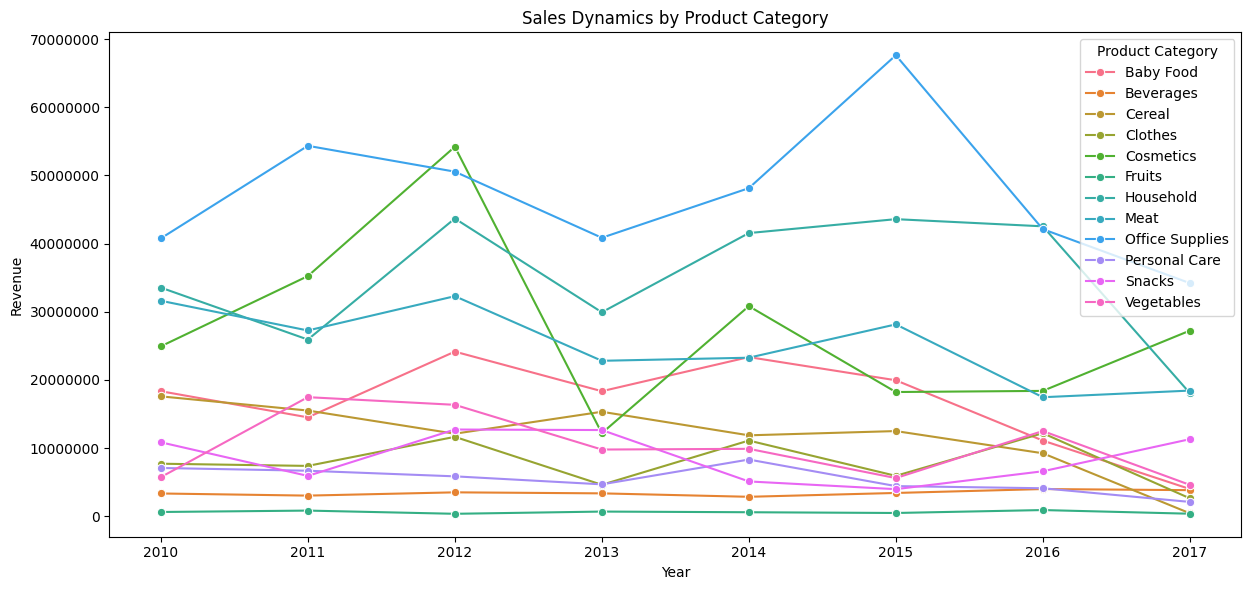

In [ ]:
# Динаміка продажів за категоріями товарів по роках
final_merged_data['order_year'] = pd.to_datetime(final_merged_data['Order Date']).dt.year

# Загальна сума по категоріях
category_year = final_merged_data.groupby(['order_year', 'item_type']).agg({'total_revenue': 'sum'}).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=category_year, x='order_year', y='total_revenue', hue='item_type', marker='o')
plt.title('Sales Dynamics by Product Category')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.legend(title='Product Category')
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## Опис візуалізації та бізнес-висновки

### Група I: cтратегічні драйвери
   * Office Supplies - безумовний лідер продажів. Продажі категорії зростали від 2010 до 2015 року, досягнувши піку близько 68 млн (2015 рік), після чого спостерігається різкий спад до 2017 року, але обсяги все одно залишаються високими. Це може бути пов'язано зі зміною постачальника, виходом на ринок сильного конкурента або зміною попиту (наприклад, перехід компаній на "безпаперовий" документообіг).
   * Meat - стабільний, високодохідний продукт. Продажі мають стійке зростання з 2010 по 2012 рік (пік близько 55 млн), після чого спостерігається помірний спад та стабілізація на рівні близько 40 млн до 2017 року. Варто оптимізувати асортимент та витрати, щоб підвищити прибутковість.
### Група II: середній потенціал
   * Household, Cosmetics, Clothes, Baby Food - категорії із середніми обсягами продажів, які демонструють високі коливання (волатильність) або мають потенціал для зростання, але потребують додаткових інвестицій для стабілізації.
### Група III: низькопріоритетні
   * Personal Care, Snacks, Beverages, Fruits, Vegetables - категорії з найнижчими абсолютними обсягами продажів, більшість з яких демонструє стійку стагнацію або падіння продажів протягом усього періоду.


Стратегія розвитку: дізнатись причини спаду у 2016-2017 роках категорії Office Supplies та направити ресурси на їх вирішення. Зменшити критичну залежність від Office Supplies та Meat шляхом нарощування частки доходу від перспективних сегментів з групи ІІ, щоб перетворити їх на нових, стабільних драйверів продажів. Провести аудит рентабельності для групи ІІІ та прийняти рішення щодо коригування асортименту або маркетингових стратегій.

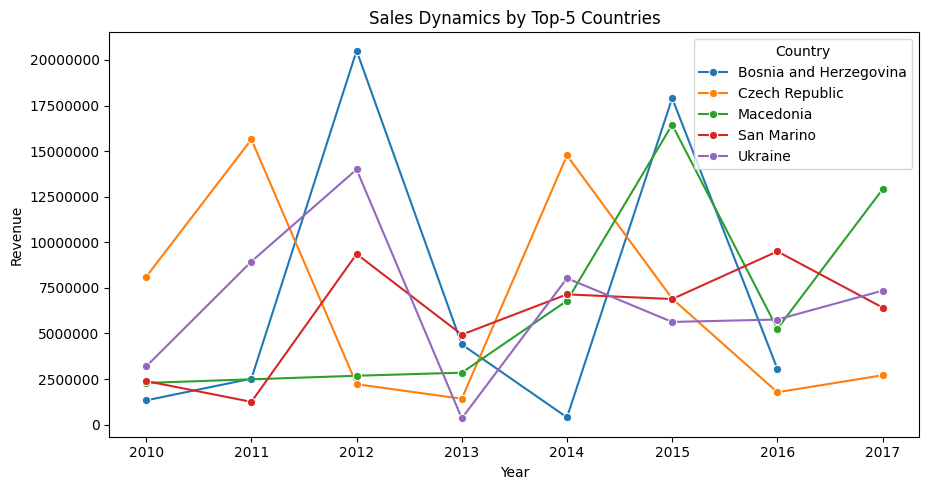

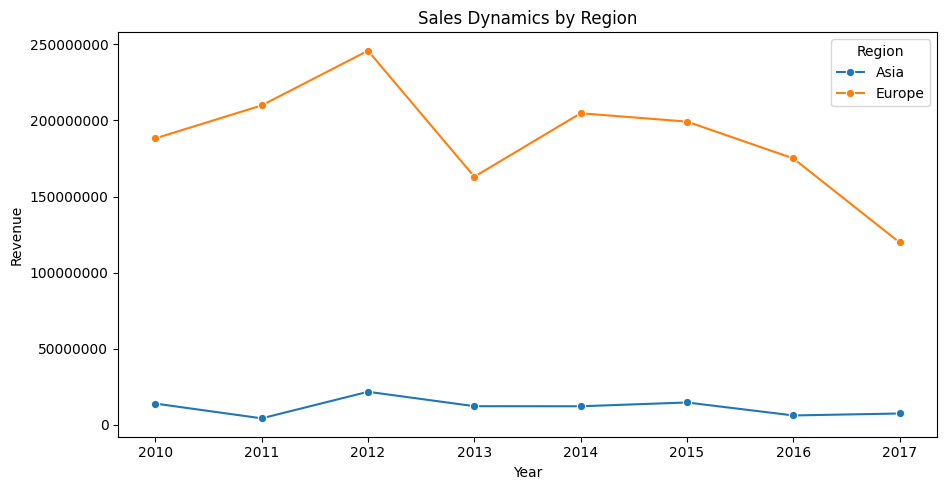

In [ ]:
# Динаміка продажів за країнами по роках
final_merged_data['order_year'] = pd.to_datetime(final_merged_data['Order Date']).dt.year

# Загальна сума по країнах
country_year = final_merged_data.groupby(['order_year', 'Country Name']).agg({'total_revenue': 'sum'}).reset_index()
# Вибираємо топ-5 країн за загальним доходом
top10_countries = (country_year.groupby("Country Name")["total_revenue"].sum().sort_values(ascending=False).head(5).index)
# Фільтруємо дані тільки по топ-5 країнах
country_year_top10 = country_year[country_year["Country Name"].isin(top10_countries)]

plt.figure(figsize=(9, 5))
sns.lineplot(data=country_year_top10, x='order_year', y='total_revenue', hue='Country Name', marker='o')

plt.title('Sales Dynamics by Top-5 Countries')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.legend(title='Country')
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Динаміка продажів за регіонами по роках

# Загальна сума по регіонах
region_year = final_merged_data.groupby(['order_year', 'region']).agg({'total_revenue': 'sum'}).reset_index()

plt.figure(figsize=(9, 5))
sns.lineplot(data=region_year, x='order_year', y='total_revenue', hue='region', marker='o')

plt.title('Sales Dynamics by Region')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.legend(title='Region')
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## Опис візуалізації

Незважаючи на високі обсяги, загальна тенденція в Європі є спадною з 2012 року.
На відміну від Європи, динаміка в Азії є відносно стабільною, без різких змін, але й без ознак сильного зростання.

Стратегія розвитку для Європи:

Європа є основним, критично важливим ринком для компанії, де зосереджені основні бізнес-ресурси, клієнтська база та стратегічні інтереси, тому необхідно дослідити причини спаду. Це може бути наслідком посилення конкуренції, насичення ринку або економічного спаду в регіоні. Потрібно оновити маркетингову стратегію, щоб підтримати інтерес до продукції, зокрема, шляхом впровадження нових продуктів, які відповідають сучасним потребам європейського ринку.

Стратегія розвитку для Азії:

Оскільки продажі в Азії стабільні, але невисокі, варто розглянути можливість інвестування в розширення каналів дистрибуції. Потрібно дослідити ринок та провести адаптацію продукту під потреби азійських споживачів.

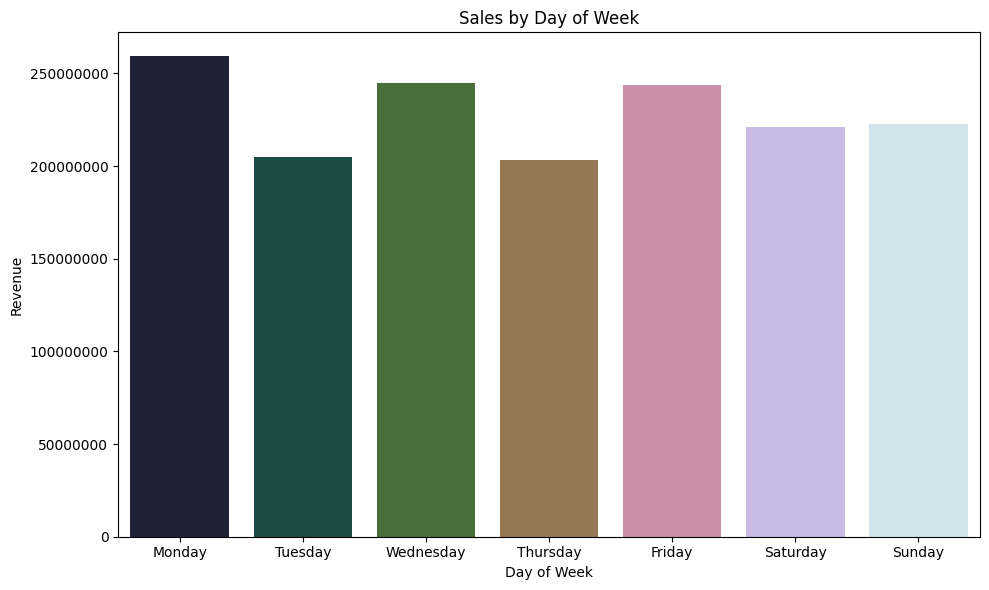

In [ ]:
# Aналіз продажів товарів за днями тижня

final_merged_data['order_day_of_week'] = final_merged_data['Order Date'].dt.dayofweek

# Загальна сума по днях тижня
sales_by_day_of_week = final_merged_data.groupby('order_day_of_week').agg({'total_revenue': 'sum'}).reset_index()

# Створюємо маппінг для днів тижня
day_of_week_map = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

# Заміна чисел на назви днів тижня
sales_by_day_of_week['day_of_week'] = sales_by_day_of_week['order_day_of_week'].map(day_of_week_map)

plt.figure(figsize=(10, 6))
sns.barplot(data=sales_by_day_of_week, x='day_of_week', y='total_revenue', palette='cubehelix', hue='day_of_week', legend=False)
plt.title('Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## Опис візуалізації

1. Найвищий дохід
   * Понеділок є днем з найвищим доходом, що перевищує 25 мільйонів.
   * Середа і п'ятниця також є днями високих продажів, з доходом близько 24,5 мільйонів кожен.
2. Найнижчий дохід
   * Вівторок та четвер є днями з найнижчим доходом, опускаючись приблизно до 20,5 мільйонів.
3. Помірний дохід
   * Субота і неділя мають практично однаковий, помірний, але стабільний рівень доходу, близько 22,5 мільйонів.

Стратегія розвитку: продажі найвищі на початку тижня, тому слід зосередити ключові акції та збільшити складські запаси на понеділок та середу. У дні з нижчим попитом (вівторок і четвер) варто запускати короткі стимулюючі пропозиції — знижки, бонуси чи спеціальні онлайн-пропозиції. Вихідні мають потенціал, тому доцільно запустити акції або спеціальні weekend-пропозиції у суботу та неділю, щоб залучити більше покупців.
